In [9]:
import pandas as pd
import openpyxl

In [10]:
path = r"H:\Phyton\3° ETAPA\indicador_mulher\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"

In [11]:
dados = pd.read_excel(path, header=2)

dados

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
...,...,...,...,...,...,...,...,...
5569,NaN,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0
5570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5571,NaN,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN,NaN
5572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
dados.columns

Index(['Unnamed: 0', 'UF', 'COD. UF', 'COD. MUNIC', 'NOME DO MUNICÍPIO',
       'População Município 2010\n(Sinopse)',
       'População 2010 (Alterações de Limites até 2022)1',
       'População Censo 2022'],
      dtype='str')

In [13]:
dados = dados.iloc[0:-3, 1:]

In [14]:
dados.columns = [
    "uf",
    "cod_uf",
    "cod_municipio",
    "municipio",
    "populacao_2010",
    "populacao_2010_compatibilizada",
    "populacao_2022"
]

In [15]:
dados

,uf,cod_uf,cod_municipio,municipio,populacao_2010,populacao_2010_compatibilizada,populacao_2022
0,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
...,...,...,...,...,...,...,...
5566,GO,52.0,22054.0,Vicentinópolis,7371.0,7373.0,8768.0
5567,GO,52.0,22203.0,Vila Boa,4735.0,4735.0,4215.0
5568,GO,52.0,22302.0,Vila Propício,5145.0,5145.0,5815.0
5569,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0


In [16]:
populacao_estado = (
    dados.groupby("uf")[[
        "populacao_2010_compatibilizada",
        "populacao_2022"
    ]]
    .sum()
    .reset_index()
)

In [17]:
populacao_estado

,uf,populacao_2010_compatibilizada,populacao_2022
0,AC,733559.0,830018.0
1,AL,3120887.0,3127683.0
2,AM,3483985.0,3941613.0
3,AP,669526.0,733759.0
4,BA,14017071.0,14141626.0
5,CE,8451644.0,8794957.0
6,DF,2572159.0,2817381.0
7,ES,3514952.0,3833712.0
8,GO,6001789.0,7056495.0
9,MA,6574789.0,6776699.0


In [18]:
populacao_estado["crescimento"] = (
    populacao_estado["populacao_2022"] -
    populacao_estado["populacao_2010_compatibilizada"]
)

In [19]:
populacao_estado = populacao_estado.sort_values(
    "crescimento",
    ascending=False
)

In [20]:
populacao_estado.to_csv(
    r"H:\Phyton\3° ETAPA\indicador_mulher\populacao_estado.csv",
    sep=";",
    index=False
)

In [21]:
populacao_municipio = dados[[
    "uf",
    "municipio",
    "populacao_2010_compatibilizada",
    "populacao_2022"
]].copy()

In [22]:
populacao_municipio

,uf,municipio,populacao_2010_compatibilizada,populacao_2022
0,RO,Alta Floresta D'Oeste,24392.0,21494.0
1,RO,Ariquemes,90353.0,96833.0
2,RO,Cabixi,6313.0,5351.0
3,RO,Cacoal,78574.0,86887.0
4,RO,Cerejeiras,17029.0,15890.0
...,...,...,...,...
5566,GO,Vicentinópolis,7373.0,8768.0
5567,GO,Vila Boa,4735.0,4215.0
5568,GO,Vila Propício,5145.0,5815.0
5569,DF,Brasília,2572159.0,2817381.0


In [23]:
populacao_municipio["crescimento"] = (
    populacao_municipio["populacao_2022"] -
    populacao_municipio["populacao_2010_compatibilizada"]
)

In [24]:
populacao_municipio = populacao_municipio.sort_values(
    "crescimento",
    ascending=False
)

In [25]:
populacao_municipio

,uf,municipio,populacao_2010_compatibilizada,populacao_2022,crescimento
111,AM,Manaus,1802014.0,2063689.0,261675.0
5569,DF,Brasília,2572159.0,2817381.0,245222.0
3829,SP,São Paulo,11253503.0,11451999.0,198496.0
3848,SP,Sorocaba,586816.0,723682.0,136866.0
5417,GO,Goiânia,1301912.0,1437366.0,135454.0
...,...,...,...,...,...
169,PA,Belém,1393399.0,1303403.0,-89996.0
3247,RJ,São Gonçalo,999728.0,896744.0,-102984.0
3242,RJ,Rio de Janeiro,6320446.0,6211223.0,-109223.0
2162,BA,Salvador,2675656.0,2417678.0,-257978.0


In [26]:
populacao_municipio.to_csv(
    r"H:\Phyton\3° ETAPA\indicador_mulher\populacao_municipio.csv",
    sep=";",
    index=False
)

In [27]:
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
ordem = populacao_estado.sort_values(
    "populacao_2022",
    ascending=False
)

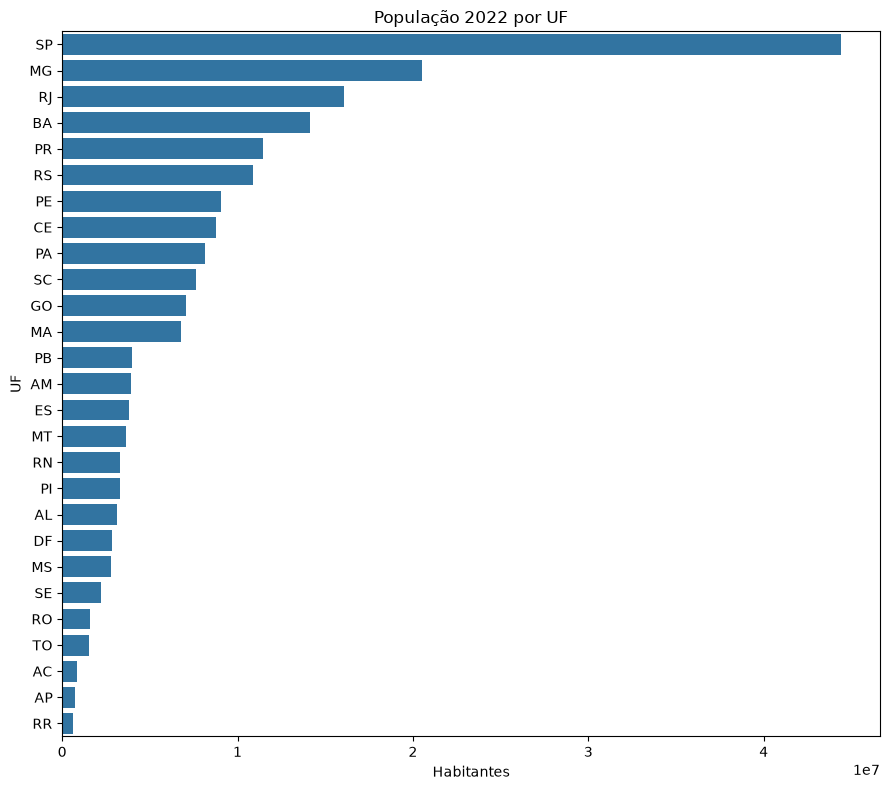

In [30]:
fig, ax = plt.subplots(figsize=(9, 8))

sns.barplot(
    data=ordem,
    y="uf",
    x="populacao_2022",
    ax=ax
)

ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")

plt.tight_layout()
plt.show()